# Food photo -> short description

Upload a food photo, send it to OpenAI Vision, and get one short Russian description such as `tarelka s gorokhovym supom 150 g.` or `yaichnitsa iz 2 yaic i 1 sosiska`.

In [13]:
import base64
import json
import mimetypes
import os
from pathlib import Path

import requests
from dotenv import load_dotenv
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

load_dotenv(PROJECT_ROOT / ".env")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
MODEL_NAME = os.getenv("OPENAI_VISION_MODEL", "gpt-5-mini")
OPENAI_URL = "https://api.openai.com/v1/responses"

if not OPENAI_API_KEY:
    raise ValueError(
        "OPENAI_API_KEY not found. Add OPENAI_API_KEY=... to the project .env file."
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Model: {MODEL_NAME}")

Project root: d:\Rustem\2_Education\7_Data_science\16_WinHack_2026
Model: gpt-5-mini


In [20]:
def resolve_image_path(image_path: str | Path) -> Path:
    path = Path(image_path)
    candidates = [
        path,
        NOTEBOOK_DIR / path,
        PROJECT_ROOT / path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Image not found: {image_path}")


def image_to_data_url(image_path: str | Path) -> str:
    resolved = resolve_image_path(image_path)
    mime_type, _ = mimetypes.guess_type(resolved.name)
    if mime_type is None:
        mime_type = "image/jpeg"

    image_bytes = resolved.read_bytes()
    encoded = base64.b64encode(image_bytes).decode("utf-8")
    return f"data:{mime_type};base64,{encoded}"


def extract_response_text(result: dict) -> str:
    output_text = (result.get("output_text") or "").strip()
    if output_text:
        return output_text

    parts = []
    for item in result.get("output", []):
        if item.get("type") != "message":
            continue
        for content in item.get("content", []):
            if content.get("type") == "output_text" and content.get("text"):
                parts.append(content["text"])

    return "\n".join(parts).strip()


def identify_food(image_path: str | Path, model: str = MODEL_NAME) -> dict:
    prompt = (
        "You analyze a food photo and return exactly one short description in English. "
        "Identify the dish and, when visible, estimate portion or count. "
        "Examples: 'a bowl of pea soup, about 150 g' or 'fried eggs from 2 eggs and 1 sausage'. "
        "Return JSON only with keys description, confidence, and assumptions. "
        "description must be one short line in English. Use English words only, no Cyrillic. "
        "confidence must be a number from 0 to 1. "
        "assumptions must be a short English string with visual assumptions, or an empty string if none."
    )

    payload = {
        "model": model,
        "input": [
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": prompt},
                    {
                        "type": "input_image",
                        "image_url": image_to_data_url(image_path),
                    },
                ],
            }
        ],
    }

    response = requests.post(
        OPENAI_URL,
        headers={
            "Authorization": f"Bearer {OPENAI_API_KEY}",
            "Content-Type": "application/json",
        },
        json=payload,
        timeout=120,
    )
    response.raise_for_status()
    result = response.json()

    raw_text = extract_response_text(result)
    if not raw_text:
        raise ValueError(
            f"Empty model response: {json.dumps(result, ensure_ascii=False)[:1000]}"
        )

    start = raw_text.find("{")
    end = raw_text.rfind("}") + 1
    if start == -1 or end <= start:
        raise ValueError(f"Expected JSON, got: {raw_text}")

    parsed = json.loads(raw_text[start:end])
    parsed["raw_response"] = raw_text
    return parsed


In [21]:
# Set your image here.
# Examples:
# IMAGE_PATH = "../assets/soup.jpg"
# IMAGE_PATH = r"D:\\photos\\breakfast.jpg"
IMAGE_PATH = "../assets/example_food_1.png"

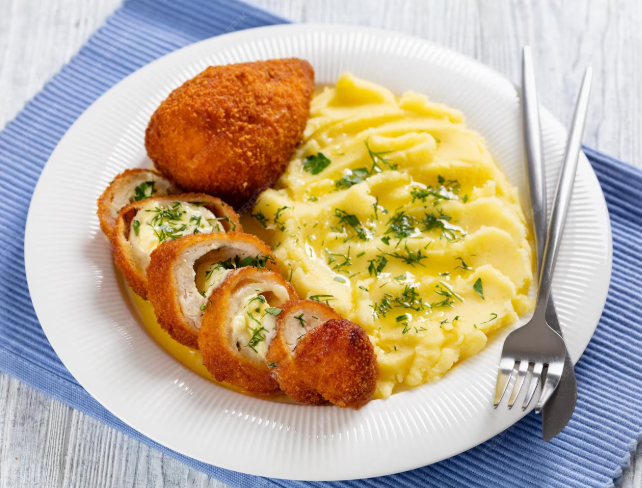

{'description': 'chicken cordon bleu (one whole piece plus three slices) with a serving of mashed potatoes',
 'confidence': 0.78,
 'assumptions': 'Assuming breaded rolled chicken is cordon bleu filled with ham/cheese and mashed potatoes portion estimated visually',
 'raw_response': '{"description":"chicken cordon bleu (one whole piece plus three slices) with a serving of mashed potatoes","confidence":0.78,"assumptions":"Assuming breaded rolled chicken is cordon bleu filled with ham/cheese and mashed potatoes portion estimated visually"}'}

In [22]:
resolved_image = resolve_image_path(IMAGE_PATH)
display(Image(filename=str(resolved_image)))

food_result = identify_food(resolved_image)
food_result

In [23]:
print(food_result["description"])

chicken cordon bleu (one whole piece plus three slices) with a serving of mashed potatoes
